## **1. Установка и Запуск Ollama**
Этот блок ставит библиотеки и запускает нейросеть.

In [ ]:
# 1. Установка библиотек
!pip install langchain-ollama langchain-chroma langchain-huggingface langchain-community chromadb tqdm python-telegram-bot pypdf nest_asyncio sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 4.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 115.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.0/731.0 kB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.2/328.2 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 99.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 69.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 476.1/476.1 kB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.3/103.3 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 111.8 MB/s e

In [ ]:
# 2. Установка Ollama
!curl -fsSL https://ollama.com/install.sh | sh

# 3. Запуск сервера и скачивание модели
import subprocess
import time

print("⏳ Запуск Ollama...")
process = subprocess.Popen(["ollama", "serve"], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
time.sleep(5)

print("⏳ Скачивание Llama 3.1 (это быстро)...")
!ollama pull llama3.1
print("✅ Готово!")

>>> Installing ollama to /usr/local
>>> Downloading Linux amd64 bundle
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
⏳ Запуск Ollama...
⏳ Скачивание Llama 3.1 (это быстро)...

✅ Готово!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **2. Подключение Google Диска**
При запуске этой ячейки появится всплывающее окно — разрешите доступ к Диску.

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

# ⚠️ ВАЖНО: Путь как на вашем скриншоте
DRIVE_BASE = "/content/drive/MyDrive/chef_lab"

if os.path.exists(DRIVE_BASE):
    print(f"✅ Папка найдена: {DRIVE_BASE}")
    print("Файлы внутри:", os.listdir(DRIVE_BASE))
else:
    print(f"❌ ОШИБКА: Папка {DRIVE_BASE} не найдена. Проверьте путь!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Папка найдена: /content/drive/MyDrive/chef_lab
Файлы внутри: ['HR_chef_bot.ipynb', 'chroma_db_backup.zip', 'Famous old receipts.pdf', 'merged_resumes.json', 'recipes.csv', 'Southern Cookbook of Fine Recipes.pdf', 'The chinese cookbook.pdf', 'The Italian cookbook.pdf', 'The white house cookbook.pdf', 'Things mother used to make.pdf', 'zavorotnyuk.pdf']


## **3. Создание config.py**
Тут мы указываем пути. Базу данных (chroma_db) будем хранить в архиве chroma_db.zip прямо в папке lab17, чтобы не пересобирать её каждый раз.

In [ ]:
%%writefile config.py
import logging
import os

logging.basicConfig(format="%(asctime)s - %(name)s - %(levelname)s - %(message)s", level=logging.INFO)
logger = logging.getLogger("HR_Chef_Bot")

# === ВАШ ТОКЕН ===
TELEGRAM_TOKEN = "8229278100:AAHP7N0KBtDiny4CR8wdECRw-GtLJStcivs"
# =================

OLLAMA_MODEL = "llama3.1"
EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"

# ДАННЫЕ С ДИСКА
DRIVE_BASE = "/content/drive/MyDrive/chef_lab"
RESUME_FILE = os.path.join(DRIVE_BASE, "merged_resumes.json")
RECIPE_FILE = os.path.join(DRIVE_BASE, "recipes.csv")
BOOK_FOLDER = DRIVE_BASE

# БАЗА ДАННЫХ
DB_PATH = "/content/chroma_work_db"
DB_BACKUP_PATH = os.path.join(DRIVE_BASE, "chroma_db_backup.zip")

HR_COLLECTION_NAME = "hr_col_v2"
FOOD_COLLECTION_NAME = "food_col_v2"
RECIPE_LIMIT = 20000 # Увеличили лимит для CSV

# === СПИСКИ КНОПОК ===

SAMPLE_HR_QUERIES = [
    "Найди React разработчика > 100к",
    "Кто самый опытный?",
    "Найди бухгалтера",
    "Python разработчик"
]

# Полный список для проверки всех книг
SAMPLE_FOOD_QUERIES = [
    "Рецепт из итальянской книги",
    "Рецепт из китайской книги",
    "Рецепт из книги Белого дома",
    "Рецепт из южной кухни",
    "Рецепт из маминой книги",
    "Старинный рецепт из книги",
    "Рецепт из книги Заворотнюк",
    "Как варить борщ? (CSV)"
]

Overwriting config.py


## **4. Создание normalizer.py**

In [ ]:
%%writefile normalizer.py
import re
import ast

def clean_text(text):
    if not text:
        return ""
    # Убираем лишние пробелы и неразрывные символы
    text = str(text).replace("\xa0", " ").replace("\r", "")
    return re.sub(r"\s+", " ", text).strip()

def normalize_resume(resume: dict) -> str:
    """
    Собирает структурированное текстовое представление резюме.
    """
    text_parts = []

    # Чтобы в поиске видеть ID
    if resume.get("id"):
        text_parts.append(f"🆔 ID: {resume['id']}")

    # Ссылка
    if resume.get("url"):
        text_parts.append(f"🔗 Ссылка: {resume['url']}")

    # --- 1. Основная информация ---
    pos = resume.get("desired_position") or resume.get("position_details", {}).get("title")
    if pos:
        text_parts.append(f"🎯 ЖЕЛАЕМАЯ ДОЛЖНОСТЬ: {clean_text(pos)}")

    salary = resume.get("salary") or resume.get("position_details", {}).get("salary")
    if salary:
        if isinstance(salary, dict):
            salary = f"{salary.get('amount', '')} {salary.get('currency', '')}"
        text_parts.append(f"💰 ЗАРПЛАТА: {clean_text(salary)}")
    else:
        text_parts.append("💰 ЗАРПЛАТА: Не указана")

    name = resume.get("personal_info", {}).get("name") or "Кандидат"
    text_parts.append(f"👤 ИМЯ: {clean_text(name)}")

    age = resume.get("personal_info", {}).get("age") or resume.get("gender_age")
    if age:
        text_parts.append(f"🎂 ВОЗРАСТ/ПОЛ: {clean_text(age)}")

    loc = resume.get("personal_info", {}).get("location") or resume.get("location_relocation")
    if loc:
        text_parts.append(f"📍 МЕСТОПОЛОЖЕНИЕ: {clean_text(loc)}")

    total_exp = resume.get("total_experience")
    if total_exp:
        text_parts.append(f"⏳ ОБЩИЙ СТАЖ: {clean_text(total_exp)}")

    # --- 2. Опыт работы ---
    experience_text = []
    raw_experience = resume.get("experience_details", [])

    for exp in raw_experience:
        if isinstance(exp, dict):
            period = str(exp.get("period", ""))
            if (
                "Специализации:" in period
                or "Права категории" in period
                or "Уровни владения" in period
            ):
                continue

            company = clean_text(exp.get("company", ""))
            position = clean_text(exp.get("position", ""))
            duration = (
                clean_text(exp.get("period", ""))
                if "месяц" in period or "год" in period
                else ""
            )
            description = exp.get("description", "")

            if not company and not position:
                continue

            exp_str = f"• {position} в «{company}»"
            if duration:
                exp_str += f" ({duration})"

            if description:
                clean_desc = re.sub(r"\n+", " ", str(description)).strip()[:300]
                exp_str += f"\n   📝 {clean_desc}..."

            experience_text.append(exp_str)

    if experience_text:
        text_parts.append("\n💼 ОПЫТ РАБОТЫ (Последние 5 мест):")
        text_parts.extend(experience_text[:5])
    else:
        text_parts.append("\n💼 ОПЫТ РАБОТЫ: Релевантный опыт не найден или не указан.")

    # --- 3. Навыки ---
    all_skills = set()
    if resume.get("skills"):
        all_skills.update(resume["skills"])

    sbl = resume.get("skills_by_level", {})
    for _, skills_list in sbl.items():
        if isinstance(skills_list, list):
            all_skills.update(skills_list)

    if all_skills:
        skills_text = ", ".join(sorted(list(all_skills))[:30])
        text_parts.append(f"\n🛠️ КЛЮЧЕВЫЕ НАВЫКИ: {skills_text}")

    # --- 4. Образование ---
    education_text = []
    edu_raw = resume.get("education_details", {}).get("higher") or resume.get("education", [])

    if isinstance(edu_raw, str):
        text_parts.append(f"\n🎓 ОБРАЗОВАНИЕ: {edu_raw}")
    elif isinstance(edu_raw, list):
        for edu in edu_raw:
            if isinstance(edu, dict):
                inst = clean_text(edu.get("institution") or edu.get("name", ""))
                det = clean_text(edu.get("details") or edu.get("organization", ""))
                if inst:
                    edu_str = f"• {inst}"
                    if det:
                        edu_str += f" ({det})"
                    education_text.append(edu_str)
        if education_text:
            text_parts.append("\n🎓 ОБРАЗОВАНИЕ:")
            text_parts.extend(education_text)

    # --- 5. О себе ---
    about = resume.get("additional_info", {}).get("about")
    if about:
        clean_about = re.sub(r"\n+", " ", str(about)).strip()[:500]
        text_parts.append(f"\n📝 О СЕБЕ: {clean_about}")

    return "\n".join(text_parts)


def normalize_recipe_csv(row: dict) -> str:
    """Для рецептов CSV (Povarenok) с красивым парсингом ингредиентов"""
    name = row.get("name", "Без названия")
    url = row.get("url", "Нет ссылки")
    raw_ing = row.get("ingredients", "{}")

    # Пытаемся превратить строку "{'Соль': '1 ч.л.'}" в красивый текст
    ing_text = raw_ing
    try:
        ing_dict = ast.literal_eval(raw_ing)
        if isinstance(ing_dict, dict):
            items = []
            for k, v in ing_dict.items():
                if v:
                    items.append(f"- {k}: {v}")
                else:
                    items.append(f"- {k}")
            ing_text = "\n".join(items)
    except:
        pass  # Если не вышло, оставляем как есть

    return f"🍳 БЛЮДО: {name}\n🔗 Ссылка: {url}\n🛒 ИНГРЕДИЕНТЫ:\n{ing_text}"

Writing normalizer.py


## **5. Создание data_loader.py (Читает все PDF)**

In [ ]:
%%writefile data_loader.py
import json
import csv
import os
import glob
import logging
from langchain_core.documents import Document
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from config import logger, RESUME_FILE, RECIPE_FILE, BOOK_FOLDER, RECIPE_LIMIT
from normalizer import normalize_resume, normalize_recipe_csv

# === ГЛУШИМ ШУМНЫЕ ЛОГИ PYPDF ===
logging.getLogger("pypdf").setLevel(logging.ERROR)

def load_resumes():
    docs = []
    if not os.path.exists(RESUME_FILE):
        logger.warning(f"Файл {RESUME_FILE} не найден!")
        return docs
    try:
        with open(RESUME_FILE, "r", encoding="utf-8") as f:
            data = json.load(f)
        for item in data.get("resumes", []):
            text = normalize_resume(item)
            docs.append(Document(page_content=text, metadata={"source": "resume", "id": item.get("id")}))
        logger.info(f"✅ Резюме загружено: {len(docs)}")
    except Exception as e: logger.error(f"JSON Error: {e}")
    return docs

def load_recipes_csv():
    docs = []
    if not os.path.exists(RECIPE_FILE): return docs
    try:
        with open(RECIPE_FILE, "r", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            for i, row in enumerate(reader):
                if i >= RECIPE_LIMIT: break
                docs.append(Document(page_content=normalize_recipe_csv(row), metadata={"source": "csv_povarenok"}))
        logger.info(f"✅ CSV рецепты загружены: {len(docs)}")
    except Exception as e: logger.error(f"CSV Error: {e}")
    return docs

def load_all_books():
    """Читает ВСЕ PDF файлы из папки"""
    docs = []
    # Ищем все PDF в папке
    pdf_files = glob.glob(os.path.join(BOOK_FOLDER, "*.pdf"))

    if not pdf_files:
        logger.warning("PDF книги не найдены.")
        return docs

    logger.info(f"📚 Найдено книг: {len(pdf_files)}")

    # Чуть уменьшили чанк, чтобы рецепты были более атомарными
    splitter = RecursiveCharacterTextSplitter(chunk_size=1500, chunk_overlap=200)

    for pdf_path in pdf_files:
        filename = os.path.basename(pdf_path)
        logger.info(f"   📖 Обработка книги: {filename}...")
        try:
            loader = PyPDFLoader(pdf_path)
            pages = loader.load()
            chunks = splitter.split_documents(pages)
            for doc in chunks:
                doc.metadata["source"] = f"book_{filename}" # Сохраняем имя книги
                doc.page_content = f"[ИСТОЧНИК: {filename}]\n{doc.page_content}"
                docs.append(doc)
        except Exception as e:
            logger.error(f"Ошибка при чтении {filename}: {e}")

    logger.info(f"✅ Всего фрагментов книг: {len(docs)}")
    return docs

Writing data_loader.py


## **6. Создание database.py (Сохранение на Диск)**

In [ ]:
%%writefile database.py
import os
import shutil
from tqdm import tqdm
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from config import logger, DB_PATH, DB_BACKUP_PATH, EMBEDDING_MODEL, HR_COLLECTION_NAME, FOOD_COLLECTION_NAME
from data_loader import load_resumes, load_recipes_csv, load_all_books

embeddings = HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL)

def get_db(collection_name):
    return Chroma(collection_name=collection_name, embedding_function=embeddings, persist_directory=DB_PATH)

def restore_db_from_drive():
    """Восстанавливает базу с Google Диска, если она там есть"""
    if os.path.exists(DB_BACKUP_PATH):
        logger.info("📦 Нашел резервную копию базы на Диске! Восстанавливаю...")
        shutil.unpack_archive(DB_BACKUP_PATH, DB_PATH, 'zip')
        logger.info("✅ База восстановлена. Индексация не требуется.")
        return True
    return False

def backup_db_to_drive():
    """Сохраняет базу на Google Диск"""
    logger.info("💾 Сохраняю базу данных на Google Диск...")
    base_name = DB_BACKUP_PATH.replace(".zip", "")
    shutil.make_archive(base_name, 'zip', DB_PATH)
    logger.info("✅ Бэкап сохранен!")

def init_db_if_empty():
    # 1. Сначала пробуем восстановить из архива
    if restore_db_from_drive():
        return

    # 2. Если архива нет - создаем с нуля
    db_hr = get_db(HR_COLLECTION_NAME)
    db_food = get_db(FOOD_COLLECTION_NAME)

    updated = False

    # HR
    if db_hr._collection.count() == 0:
        logger.info("⚠️ Индексация Резюме (займет время)...")
        data = load_resumes()
        if data:
            for i in tqdm(range(0, len(data), 500)): db_hr.add_documents(data[i:i+500])
            updated = True

    # FOOD (CSV + ВСЕ КНИГИ)
    if db_food._collection.count() == 0:
        logger.info("⚠️ Индексация Еды (CSV + PDF)...")
        data = load_recipes_csv() + load_all_books()
        if data:
            for i in tqdm(range(0, len(data), 500)): db_food.add_documents(data[i:i+500])
            updated = True

    # 3. Сохраняем на Диск
    if updated:
        backup_db_to_drive()

def force_reload_db():
    if os.path.exists(DB_PATH):
        shutil.rmtree(DB_PATH)
    init_db_if_empty()
    return True

Writing database.py


## **7. Создание chains.py (Сортировка + Классификатор)**

In [ ]:
%%writefile chains.py
import asyncio
import re
from langchain_ollama import ChatOllama
from config import OLLAMA_MODEL, logger, HR_COLLECTION_NAME, FOOD_COLLECTION_NAME
from database import get_db

# --- НАСТРОЙКИ ---
HR_FETCH_K = 30
HR_FINAL_K = 6

# Увеличиваем глубину поиска для еды до 300!
# Это критично, чтобы найти 1 книгу среди 20000 рецептов CSV.
FOOD_FETCH_K = 300
FOOD_FINAL_K = 5

# Температура 0.1 для стабильности
llm = ChatOllama(model=OLLAMA_MODEL, temperature=0.1)

# --- DATABASE ---
def get_hr_db(): return get_db(HR_COLLECTION_NAME)
def get_food_db(): return get_db(FOOD_COLLECTION_NAME)

# ==========================================
#               HR LOGIC (RESUMES)
# ==========================================

def rerank_hr_docs(query, docs):
    q_lower = query.lower()
    techs = ["react", "python", "java", "c++", "php", "1c", "sql", "js", "node", "linux", "html", "css", "senior", "middle"]
    targets = [t for t in techs if t in q_lower]

    if not targets: return docs[:HR_FINAL_K]

    scored = []
    for doc in docs:
        score = 0
        for t in targets:
            if t in doc.page_content.lower(): score += 10
        scored.append((score, doc))
    scored.sort(key=lambda x: x[0], reverse=True)
    return [x[1] for x in scored][:HR_FINAL_K]

def format_hr_sources(results):
    blocks = []
    for i, doc in enumerate(results):
        c = doc.page_content
        did = doc.metadata.get('id', '')[-4:]
        def g(m):
            r = re.search(f"{re.escape(m)} (.*?)(\n|$)", c)
            return r.group(1).strip() if r else "?"

        pos, sal, exp, skills, link = g("🎯 ЖЕЛАЕМАЯ ДОЛЖНОСТЬ:"), g("💰 ЗАРПЛАТА:"), g("⏳ ОБЩИЙ СТАЖ:"), g("🛠️ КЛЮЧЕВЫЕ НАВЫКИ:"), g("🔗 Ссылка:")
        if len(skills) > 50: skills = skills[:50] + "..."

        blocks.append(f"**{i+1}. {pos}** `[...{did}]`\n⏳ {exp}\n💰 {sal}\n🛠 {skills}\n🔗 [Резюме]({link})")
    return "\n\n".join(blocks)

async def run_hr_query(query: str):
    db = get_hr_db()
    raw = db.similarity_search(query, k=HR_FETCH_K)
    if not raw: return "❌ Резюме не найдены."

    best = rerank_hr_docs(query, raw)
    ctx = "".join([f"=== КАНДИДАТ {i+1} ===\n{d.page_content}\n\n" for i, d in enumerate(best)])

    # Промпт HR оставлен без изменений, как вы и просили
    prompt = f"""
    [SYSTEM: YOU ARE A SENIOR HR RECRUITER. ANSWER STRICTLY IN RUSSIAN.]

    USER REQUEST: "{query}"
    TOP CANDIDATES LIST:
    {ctx}

    TASK:
    1. Analyze the User Request.
    2. Select ONE single best candidate who matches requirements.
       - Prioritize EXPLICIT matching salary over "Not specified".
       - Prioritize candidates with required skills.
    3. Write a short recommendation.

    OUTPUT FORMAT:
    "✅ **Рекомендую кандидата №[N]** ([Должность])
    📊 **Почему он:** [Объяснение на русском]"
    """
    msg = await llm.ainvoke(prompt)
    return f"{msg.content}\n\n___\n🔍 *ТОП-{len(best)} КАНДИДАТОВ:*\n{format_hr_sources(best)}"


# ==========================================
#             FOOD LOGIC (UPDATED)
# ==========================================

def rerank_food_docs(query, docs):
    q_lower = query.lower()

    scored = []
    for doc in docs:
        score = 0
        src = doc.metadata.get('source', '').lower()
        content = doc.page_content.lower()

        # --- 1. ЖЕСТКАЯ ПРИВЯЗКА К КНИГАМ ---

        # Китайская
        if ("китай" in q_lower or "chinese" in q_lower) and "chinese" in src: score += 5000
        # Итальянская
        if ("итальян" in q_lower or "italian" in q_lower) and "italian" in src: score += 5000
        # Белый дом
        if ("бел" in q_lower and "дом" in q_lower or "white house" in q_lower) and "white" in src: score += 5000
        # Южная
        if ("южн" in q_lower or "southern" in q_lower) and "southern" in src: score += 5000
        # Мамина
        if ("мам" in q_lower or "mother" in q_lower) and "mother" in src: score += 5000
        # Старинные
        if ("старин" in q_lower or "old" in q_lower) and "famous" in src: score += 5000
        # Заворотнюк
        if "заворотнюк" in q_lower and "zavorotnyuk" in src: score += 5000

        # --- 2. ОБЩИЕ ПРАВИЛА ---
        # Если просят книгу — топим CSV, поднимаем PDF
        if any(w in q_lower for w in ["книг", "book", "pdf"]):
            if "book_" in src: score += 500
            else: score -= 500

        # Если просят английский
        if any(w in q_lower for w in ["англ", "english", "foreign"]):
            if "book_" in src and "zavorotnyuk" not in src: score += 300

        # Совпадение по ингредиентам (перевод ключевых слов)
        if "десерт" in q_lower and any(x in content for x in ["dessert", "cake", "pie", "tart", "sweet"]): score += 50
        if "куриц" in q_lower and any(x in content for x in ["chicken", "poultry"]): score += 50

        scored.append((score, doc))

    scored.sort(key=lambda x: x[0], reverse=True)
    return [x[1] for x in scored][:FOOD_FINAL_K]

def format_food_sources(results):
    blocks = []
    for i, doc in enumerate(results):
        c = doc.page_content
        src = doc.metadata.get('source', '')

        if "book_" in src:
            clean_name = src.replace("book_", "").replace(".pdf", "")
            title = f"📖 Книга: {clean_name}"
            preview = c.replace("[ИСТОЧНИК: " + src.replace("book_", "") + "]", "").strip()[:100].replace("\n", " ") + "..."
            body = f"📝 _{preview}_"
        else:
            title = "🌐 Поваренок.ру"
            def g(m):
                r = re.search(f"{re.escape(m)} (.*?)(\n|$)", c)
                return r.group(1).strip() if r else "?"
            dish, link = g("🍳 БЛЮДО:"), g("🔗 Ссылка:")
            body = f"🍲 {dish}\n🔗 [Рецепт]({link})"

        blocks.append(f"**{i+1}.** {title}\n{body}")
    return "\n\n".join(blocks)

async def run_food_query(query: str):
    db = get_food_db()
    # Ищем широко (300), чтобы найти редкие книги
    raw = db.similarity_search(query, k=FOOD_FETCH_K)
    if not raw: return "❌ База рецептов пуста."

    best = rerank_food_docs(query, raw)

    ctx = ""
    for i, d in enumerate(best):
        src = d.metadata.get('source', '')
        lang_hint = "RUSSIAN" if "povarenok" in src or "zavorotnyuk" in src else "ENGLISH"
        ctx += f"=== RECIPE {i+1} (Source: {src}, Lang: {lang_hint}) ===\nCONTENT: {d.page_content[:2000]}\n\n"

    # Усиленный промпт для перевода
    prompt = f"""
    [SYSTEM: EXPERT CHEF. OUTPUT LANGUAGE: RUSSIAN ONLY.]

    USER REQUEST: "{query}"

    CONTEXT RECIPES:
    {ctx}

    INSTRUCTIONS:
    1. Find a recipe that matches the User Request in the Context.
    2. IF THE SOURCE IS ENGLISH (Lang: ENGLISH):
       - **TRANSLATE EVERYTHING TO RUSSIAN**.
       - Title, Ingredients, Instructions -> ALL IN RUSSIAN.
    3. If specific book requested, use only that source.
    4. If not found, say "Не нашел в этой книге".
    """
    msg = await llm.ainvoke(prompt)
    return f"{msg.content}\n\n___\n🔍 *ИСТОЧНИКИ:*\n{format_food_sources(best)}"

async def classify_and_run(text: str):
    t_up = text.upper()

    hr_kw = ["REACT", "PYTHON", "JAVA", "1С", "IT", "ЗАРПЛАТА", "РЕЗЮМЕ", "КАНДИДАТ", "ОПЫТ", "СТАЖ", "ЛЕТ", "НАЙДИ", "КТО"]
    if any(w in t_up for w in hr_kw): return await run_hr_query(text)

    food_kw = ["РЕЦЕПТ", "СУП", "БОРЩ", "ПОВАР", "КУРИЦ", "БЛЮДО", "КАК ГОТОВИТЬ", "КУХНЯ", "ТОРТ", "САЛАТ", "КНИГ", "BOOK", "OLD", "FAMOUS", "WHITE HOUSE"]
    if any(w in t_up for w in food_kw): return await run_food_query(text)

    try:
        intent = await llm.ainvoke(f"Is '{text}' about HR/RESUMES or FOOD/RECIPES? Reply ONE WORD.")
        return await run_hr_query(text) if "HR" in intent.content.upper() else await run_food_query(text)
    except: return "⚠️ Ошибка классификации."

Writing chains.py


## **8. Файлы интерфейса и запуск**

In [ ]:
%%writefile keyboards.py
from telegram import ReplyKeyboardMarkup, KeyboardButton
from config import SAMPLE_HR_QUERIES, SAMPLE_FOOD_QUERIES

def build_menu(buttons, n_cols, header_buttons=None, footer_buttons=None):
    """Вспомогательная функция для создания сетки кнопок"""
    menu = [buttons[i:i + n_cols] for i in range(0, len(buttons), n_cols)]
    if header_buttons:
        menu.insert(0, header_buttons)
    if footer_buttons:
        menu.append(footer_buttons)
    return menu

def get_main_keyboard():
    keyboard = [
        [KeyboardButton("👨‍💻 Подбор персонала"), KeyboardButton("🍲 Кулинарная книга")],
        [KeyboardButton("🎲 Случайный запрос"), KeyboardButton("ℹ️ Помощь")],
        [KeyboardButton("🔄 Обновить базу")]
    ]
    return ReplyKeyboardMarkup(keyboard, resize_keyboard=True)

def get_hr_keyboard():
    # Создаем кнопки из списка
    button_list = [KeyboardButton(q) for q in SAMPLE_HR_QUERIES]
    # Строим меню: 2 колонки + кнопка "Назад" внизу
    menu = build_menu(button_list, n_cols=2, footer_buttons=[KeyboardButton("🔙 Главное меню")])
    return ReplyKeyboardMarkup(menu, resize_keyboard=True)

def get_food_keyboard():
    # Создаем кнопки из списка
    button_list = [KeyboardButton(q) for q in SAMPLE_FOOD_QUERIES]
    # Строим меню: 2 колонки + кнопка "Назад" внизу
    menu = build_menu(button_list, n_cols=2, footer_buttons=[KeyboardButton("🔙 Главное меню")])
    return ReplyKeyboardMarkup(menu, resize_keyboard=True)

Writing keyboards.py


In [ ]:
%%writefile main.py
import nest_asyncio
nest_asyncio.apply()

import logging
import asyncio
import os
import random
from telegram import Update
from telegram.ext import ApplicationBuilder, CommandHandler, MessageHandler, filters
from config import TELEGRAM_TOKEN, SAMPLE_HR_QUERIES, SAMPLE_FOOD_QUERIES, DB_PATH
from chains import classify_and_run
from database import init_db_if_empty, force_reload_db
import keyboards as kb

# Настройка логов (убираем лишний шум)
logging.basicConfig(format="%(asctime)s - %(name)s - %(levelname)s - %(message)s", level=logging.INFO)
logging.getLogger("httpx").setLevel(logging.WARNING)

logger = logging.getLogger("HR_Chef_Bot")

# --- ОБРАБОТЧИКИ ---

async def start(u: Update, c):
    await u.message.reply_text(
        "👋 **Привет! Я AI-помощник.**\n\n"
        "Я ищу:\n"
        "👔 Кандидатов (в резюме)\n"
        "🥗 Рецепты (в CSV и Книгах)\n\n"
        "👇 Выберите режим в меню:",
        reply_markup=kb.get_main_keyboard(),
        parse_mode="Markdown"
    )

async def help_cmd(u: Update, c):
    text = (
        "ℹ️ **Справка:**\n\n"
        "🔹 **HR**: Ищу в `merged_resumes.json`.\n"
        "🔹 **Еда**: Ищу в `recipes.csv` и **PDF книгах**.\n"
        "Если база пустая или старая — нажмите **Обновить базу**."
    )
    await u.message.reply_text(text, parse_mode="Markdown")

async def handle_message(u: Update, c):
    text = u.message.text

    # --- ЛОГИКА МЕНЮ ---
    if text == "👨‍💻 Подбор персонала":
        await u.message.reply_text(
            "🔎 **Режим HR**.\nНапишите запрос (навыки, зарплата) или выберите пример:",
            reply_markup=kb.get_hr_keyboard(),
            parse_mode="Markdown"
        )
        return

    elif text == "🍲 Кулинарная книга":
        await u.message.reply_text(
            "🍳 **Режим Повара**.\nНапишите название блюда:",
            reply_markup=kb.get_food_keyboard(),
            parse_mode="Markdown"
        )
        return

    elif text == "🔙 Главное меню":
        await u.message.reply_text(
            "Вы вернулись в главное меню.", reply_markup=kb.get_main_keyboard()
        )
        return

    elif text == "ℹ️ Помощь":
        await help_cmd(u, c)
        return

    elif text == "🔄 Обновить базу":
         msg = await u.message.reply_text("♻️ Пересобираю базу данных (ждите)...")
         try:
             force_reload_db()
             await msg.edit_text("✅ База успешно обновлена и сохранена на Диск!")
         except Exception as e:
             await msg.edit_text(f"❌ Ошибка: {e}")
         return

    elif text == "🎲 Случайный запрос":
        q = random.choice(SAMPLE_HR_QUERIES + SAMPLE_FOOD_QUERIES)
        await u.message.reply_text(f"🎲 *Пробуем:* {q}", parse_mode="Markdown")
        await process_ai(u, q)
        return

    # Обычный текст -> AI
    await process_ai(u, text)

async def process_ai(u, text):
    # Показываем статус "печатает..."
    await u.message.chat.send_action("typing")
    msg = await u.message.reply_text("⏳ _Анализирую..._", parse_mode="Markdown")

    try:
        resp = await classify_and_run(text)
        # Пробуем отправить Markdown
        try:
            await msg.edit_text(resp, parse_mode="Markdown")
        except:
            # Если Markdown сломался (спецсимволы) — шлем чистый текст
            await msg.edit_text(resp)
    except Exception as e:
        logger.error(f"AI Error: {e}")
        await msg.edit_text(f"⚠️ Ошибка обработки: {e}")

# --- ГЛАВНАЯ ФУНКЦИЯ ЗАПУСКА ---
async def main():
    # 1. Проверка диска
    from google.colab import drive
    if not os.path.exists('/content/drive'):
        drive.mount('/content/drive')

    print("📂 Инициализация базы данных...")
    # Инициализация БД
    init_db_if_empty()

    print(f"🚀 БОТ ЗАПУЩЕН! Токен: {TELEGRAM_TOKEN[:10]}...")

    # 2. Сборка приложения
    app = ApplicationBuilder().token(TELEGRAM_TOKEN).build()
    app.add_handler(CommandHandler("start", start))
    app.add_handler(CommandHandler("help", help_cmd))
    app.add_handler(MessageHandler(filters.TEXT & ~filters.COMMAND, handle_message))

    # 3. ПРАВИЛЬНЫЙ ЗАПУСК (Initialize -> Start -> Polling)
    await app.initialize()
    await app.start()
    await app.updater.start_polling()

    print("🟢 Бот слушает сообщения... (Нажмите Стоп для остановки)")

    # 4. Вечный цикл, чтобы скрипт не закрылся
    try:
        while True:
            await asyncio.sleep(10)
    except KeyboardInterrupt:
        print("🛑 Остановка бота...")
        await app.updater.stop()
        await app.stop()
        await app.shutdown()

if __name__ == "__main__":
    try:
        loop = asyncio.get_event_loop()
        loop.run_until_complete(main())
    except KeyboardInterrupt:
        pass

Writing main.py


## **9. Финальный запуск**

In [ ]:
!python main.py

2025-12-18 05:34:09,023 - numexpr.utils - INFO - NumExpr defaulting to 2 threads.
2025-12-18 05:34:11.109043: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766036051.128857    3874 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766036051.134954    3874 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766036051.151579    3874 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766036051.151605    3874 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000

## **Технические шоколадки**

### **Если упала LLM (All connection attempts failed)**

In [ ]:
import subprocess
import time

print("💀 Убиваю старые процессы Ollama...")
!pkill ollama

print("⏳ Запускаю сервер Ollama заново...")
# Запускаем сервер в фоне
process = subprocess.Popen(["ollama", "serve"], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
time.sleep(5)  # Ждем 5 секунд, пока загрузится

print("🧠 Проверяю модель Llama 3.1...")
# На всякий случай дергаем pull, чтобы убедиться, что она на месте
!ollama pull llama3.1

print("✅ Нейросеть перезапущена! Теперь перезапустите ячейку с main.py")

💀 Убиваю старые процессы Ollama...
⏳ Запускаю сервер Ollama заново...
🧠 Проверяю модель Llama 3.1...

✅ Нейросеть перезапущена! Теперь перезапустите ячейку с main.py


### **Если надо пересобрать БД**

In [ ]:
import shutil
import os
from config import DB_PATH

print(f"🧹 Удаляю старую базу данных по пути: {DB_PATH}")
if os.path.exists(DB_PATH):
    shutil.rmtree(DB_PATH)
    print("✅ Удалено. При следующем запуске main.py база соберется заново с ПРАВИЛЬНЫМИ данными.")
else:
    print("👌 Базы не было, всё чисто.")

### **Как все должно собираться без БД**

📂 Инициализация базы данных...
2025-11-26 18:52:05,503 - HR_Chef_Bot - INFO - ⚠️

Индексация Резюме (займет время)...

2025-11-26 18:52:08,952 - HR_Chef_Bot - INFO - ✅ Резюме загружено: 4836
100% 10/10 [00:37<00:00,  3.76s/it]

2025-11-26 18:52:46,607 - HR_Chef_Bot - INFO - ⚠️ Индексация Еды (CSV + PDF)...

2025-11-26 18:52:49,126 - HR_Chef_Bot - INFO - ✅ CSV рецепты загружены: 20000

2025-11-26 18:52:49,129 - HR_Chef_Bot - INFO - 📚 Найдено книг: 7

2025-11-26 18:52:49,129 - HR_Chef_Bot - INFO -    📖 Обработка книги: The chinese cookbook.pdf...

2025-11-26 18:52:51,651 - HR_Chef_Bot - INFO -    📖 Обработка книги: Southern Cookbook of Fine Recipes.pdf...

2025-11-26 18:52:55,074 - HR_Chef_Bot - INFO -    📖 Обработка книги: Famous old receipts.pdf...

2025-11-26 18:53:02,179 - HR_Chef_Bot - INFO -    📖 Обработка книги: The Italian cookbook.pdf...

2025-11-26 18:53:06,078 - HR_Chef_Bot - INFO -    📖 Обработка книги: Things mother used to make.pdf...

2025-11-26 18:53:09,223 - HR_Chef_Bot - INFO -    📖 Обработка книги: The white house cookbook.pdf...

2025-11-26 18:55:25,830 - HR_Chef_Bot - INFO -    📖 Обработка книги: zavorotnyuk.pdf...

2025-11-26 18:55:30,572 - HR_Chef_Bot - INFO - ✅ Всего фрагментов книг: 2544
100% 46/46 [01:17<00:00,  1.69s/it]

2025-11-26 18:56:48,402 - HR_Chef_Bot - INFO - 💾 Сохраняю базу данных на Google Диск...

2025-11-26 18:57:00,318 - HR_Chef_Bot - INFO - ✅ Бэкап сохранен!

🚀 БОТ ЗАПУЩЕН! Токен: 8465433286...
2025-11-26 18:57:01,002 - telegram.ext.Application - INFO - Application started

🟢 Бот слушает сообщения... (Нажмите Стоп для остановки)

### 1. Архитектура Блокнота №2: `HR_chef_bot.ipynb`
**Тип:** Прикладной / Production-like
**Цель:** Создать Telegram-бота с персистентной (сохраняемой) базой, сложной логикой маршрутизации запросов и поддержкой разных типов документов (PDF, CSV, JSON).


#### Ключевые отличия и компоненты:

1.  **Infrastructure (Инфраструктура):**
    *   **Ollama Server:** LLM запускается как отдельный локальный веб-сервер внутри Colab. Это позволяет основному скрипту (боту) обращаться к ней асинхронно.
    *   **Модель:** `Llama 3.1` (8B) — мощная модель общего назначения.

2.  **Data Ingestion (Продвинутый загрузчик):**
    *   **Мультиформатность:**
        *   `JSON` (Резюме) -> Нормализация в текст.
        *   `CSV` (Рецепты) -> Парсинг ингредиентов в читаемый вид.
        *   `PDF` (Книги) -> Использование `PyPDFLoader` + `RecursiveCharacterTextSplitter` (нарезка текста на чанки по 1500 символов с перекрытием).
    *   **Метаданные:** При загрузке каждому документу присваивается `source` (например, "book_zavorotnyuk.pdf" или "resume"), что критически важно для ранжирования.

3.  **Vector Store (Персистентная база):**
    *   **Технология:** `ChromaDB`.
    *   **Хранение:** База физически сохраняется на диск (`/content/chroma_work_db`), архивируется в ZIP и **отправляется на Google Drive**.
    *   **Разделение:** Две независимые коллекции (`hr_col_v2` и `food_col_v2`), чтобы рецепты супа не смешивались с навыками Python-разработчиков.

4.  **Retrieval Strategy (Стратегия поиска):**
    *   **Router (Классификатор):** Функция `classify_and_run` определяет тему запроса (HR или Еда) по ключевым словам или через LLM, направляя запрос в нужную коллекцию.
    *   **Broad Fetch (Широкий захват):** Сначала извлекается много документов (30 для HR, **300** для Еды).
    *   **Python Re-ranking (Умная сортировка):**
        *   *HR:* Начисляет баллы резюме, если в тексте есть ключевые слова из запроса (React, Python и т.д.).
        *   *Еда:* Сложная логика. Если пользователь просит "книгу" — приоритет PDF-файлам. Если просит "старинный рецепт" — приоритет конкретному файлу `Famous old receipts.pdf`.

5.  **Generation & Prompt Engineering:**
    *   Используются **системные промпты**, задающие роль:
        *   `[SYSTEM: SENIOR HR RECRUITER]` — для резюме.
        *   `[SYSTEM: EXPERT CHEF]` — для рецептов (с указанием переводить всё на русский язык).

### Сравнение подходов

| Характеристика | Блокнот 1 (Intro) | Блокнот 2 (HR Chef Bot) |
| :--- | :--- | :--- |
| **База знаний** | RAM (FAISS), пропадает при выходе | Disk/Cloud (ChromaDB + Google Drive) |
| **LLM** | Внутри Python процесса (HF Pipeline) | Внешний сервис (Ollama API) |
| **Логика поиска** | Simple Semantic Search (L2 distance) | Semantic Search + **Logic-based Re-ranking** |
| **Обработка данных** | Простая строка | PDF Parsing, Chunking, Cleaning |
| **Интерфейс** | `print()` в консоль | Telegram Bot API |
| **Масштабируемость** | Низкая (учебный пример) | Высокая (разделение коллекций, бэкапы) |

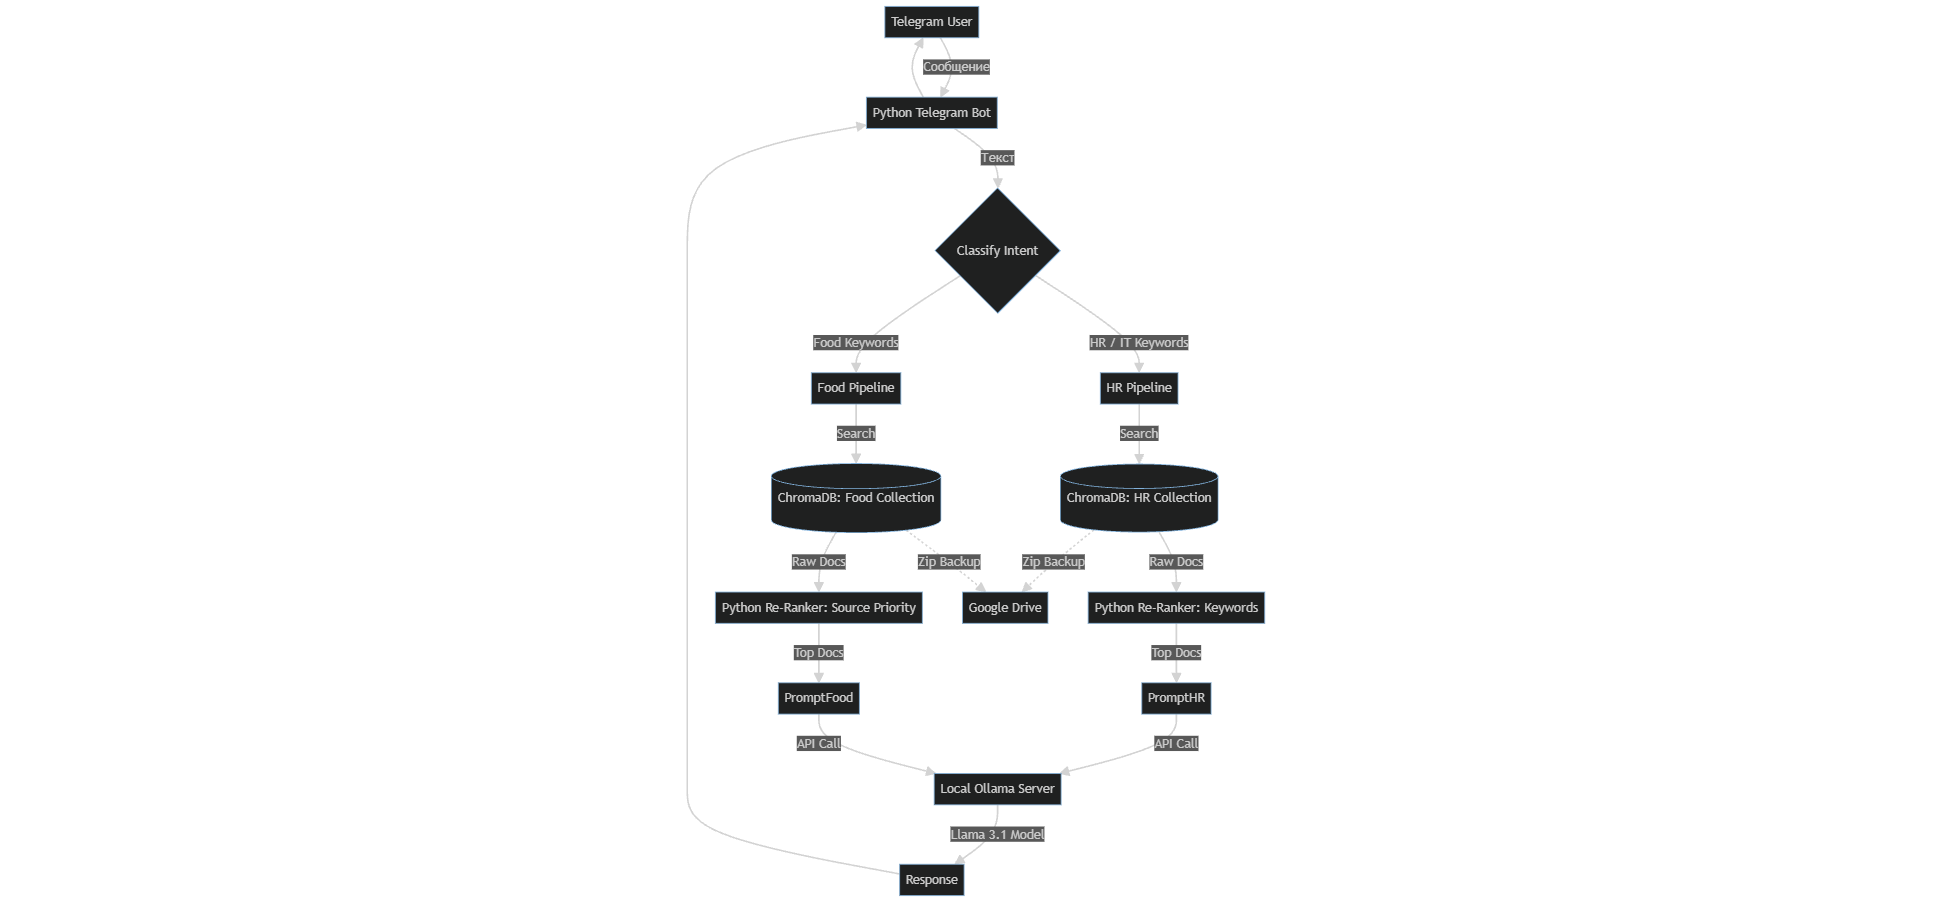